In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

dataset_dir = r'C:\Users\gragh\Projects On VS Code\Skin Analyzer\Skin Conditions'
dataset = image_dataset_from_directory(
    dataset_dir,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

def split_dataset(dataset, train_size=0.8, val_size=0.1, test_size=0.1):
    total_size = len(dataset)
    train_end = int(total_size * train_size)
    val_end = train_end + int(total_size * val_size)
    
    train_dataset = dataset.take(train_end)
    val_dataset = dataset.skip(train_end).take(val_end - train_end)
    test_dataset = dataset.skip(val_end)
    
    return train_dataset, val_dataset, test_dataset

train_dataset, val_dataset, test_dataset = split_dataset(dataset)

Found 2000 files belonging to 6 classes.


In [3]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [4]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

def augment_data(dataset):
    def augment(image, label):
        image = data_augmentation(image)
        return image, label

    return dataset.map(augment)

train_dataset = augment_data(train_dataset)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    batch_size=32
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.3989 - loss: 1.7070 - val_accuracy: 0.8073 - val_loss: 0.5375
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.7715 - loss: 0.6765 - val_accuracy: 0.8438 - val_loss: 0.4219
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.7959 - loss: 0.5650 - val_accuracy: 0.8594 - val_loss: 0.3766
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8627 - loss: 0.4140 - val_accuracy: 0.9062 - val_loss: 0.3364
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8795 - loss: 0.3570 - val_accuracy: 0.8802 - val_loss: 0.3530
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8887 - loss: 0.3069 - val_accuracy: 0.8854 - val_loss: 0.2989
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8981 - loss: 0.2783 - val_accuracy: 0.9479 - val_loss: 0.2257
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.9067 - loss: 0.2706 - val_accuracy: 0.9323 - val_los

In [5]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9600 - loss: 0.1536
Test Accuracy: 0.9471


In [6]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_fine_tune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    batch_size=32
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9100 - loss: 0.2845 - val_accuracy: 0.9583 - val_loss: 0.1415
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9449 - loss: 0.2136 - val_accuracy: 0.9531 - val_loss: 0.1717
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.9524 - loss: 0.1905 - val_accuracy: 0.9583 - val_loss: 0.1703
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.9471 - loss: 0.1759 - val_accuracy: 0.9375 - val_loss: 0.1745
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9457 - loss: 0.1575 - val_accuracy: 0.9583 - val_loss: 0.1477
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.9565 - loss: 0.1501 - val_accuracy: 0.9792 - val_loss: 0.0939
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.9545 - loss: 0.1524 - val_accuracy: 0.9688 - val_loss: 0.1189
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9732 - loss: 0.1262 - val_accuracy: 0.9688 - v

In [7]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9657 - loss: 0.1120
Test Accuracy: 0.9567


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


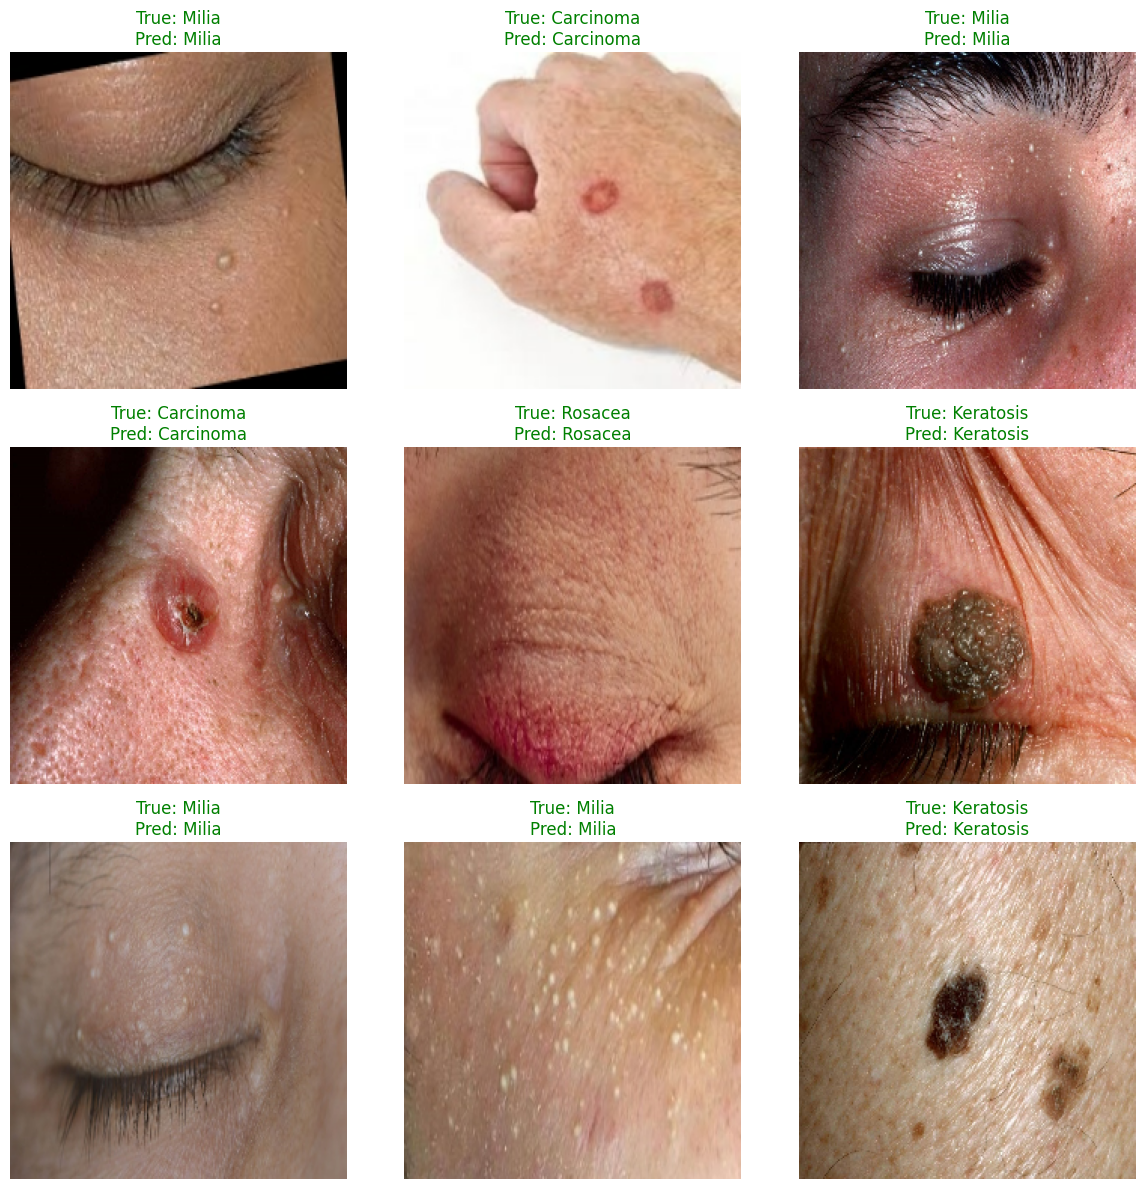

In [10]:
import matplotlib.pyplot as plt

class_names = [
    'Acne',
    'Carcinoma',
    'Eczema',
    'Keratosis',
    'Milia',
    'Rosacea'
]

def plot_random_images(test_dataset, model, class_names, num_images=9):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()
    
    for image_batch, label_batch in test_dataset.take(1):
        predictions = model.predict(image_batch)
        predicted_labels = np.argmax(predictions, axis=1)
        indices = np.random.choice(len(image_batch), num_images, replace=False)
        
        for idx, ax in enumerate(axes):
            img = image_batch[indices[idx]].numpy().astype(np.uint8)
            true_label = label_batch[indices[idx]].numpy()
            pred_label = predicted_labels[indices[idx]]
            
            ax.imshow(img)
            ax.axis('off')
            
            true_label_name = class_names[true_label]
            pred_label_name = class_names[pred_label]
            title_color = 'green' if true_label == pred_label else 'red'
            ax.set_title(f"True: {true_label_name}\nPred: {pred_label_name}", color=title_color, fontsize=12)
    
    plt.tight_layout()
    plt.show()

plot_random_images(test_dataset, model, class_names)

In [9]:
model.save('skin_conditions_model.h5')
